In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from pathlib import Path
from tqdm.auto import tqdm

import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
path = kagglehub.dataset_download("briscdataset/brisc2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brisc2025' dataset.
Path to dataset files: /kaggle/input/brisc2025


In [7]:
import os
from pathlib import Path

print("Dataset path:")
print(path)

print("\nTop-level contents:")
for item in Path(path).iterdir():
    print(item)

Dataset path:
/kaggle/input/brisc2025

Top-level contents:
/kaggle/input/brisc2025/brisc2025


In [8]:
print("\nComplete folder structure:\n")

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

    if level > 4:
        dirs[:] = []


Complete folder structure:

brisc2025/
    brisc2025/
        manifest.json
        README.md
        manifest.csv
        manifest.json.sha256
        manifest.csv.sha256
        segmentation_task/
            test/
                images/
                    brisc2025_test_00560_me_sa_t1.jpg
                    brisc2025_test_00949_pi_sa_t1.jpg
                    brisc2025_test_00177_gl_sa_t1.jpg
                    brisc2025_test_00799_pi_ax_t1.jpg
                    brisc2025_test_00705_pi_ax_t1.jpg
                    brisc2025_test_00510_me_sa_t1.jpg
                    brisc2025_test_00180_gl_sa_t1.jpg
                    brisc2025_test_00061_gl_ax_t1.jpg
                    brisc2025_test_00551_me_sa_t1.jpg
                    brisc2025_test_01000_pi_sa_t1.jpg
                masks/
                    brisc2025_test_00855_pi_co_t1.png
                    brisc2025_test_00748_pi_ax_t1.png
                    brisc2025_test_00446_me_co_t1.png
                    brisc2025_tes

In [9]:
from pathlib import Path

dataset_path = Path(path)

# Find the segmentation_task directory automatically
segmentation_path = next(
    dataset_path.rglob("segmentation_task")
)

print("Segmentation path:")
print(segmentation_path)

Segmentation path:
/kaggle/input/brisc2025/brisc2025/segmentation_task


In [10]:
train_images_dir = segmentation_path / "train" / "images"
train_masks_dir = segmentation_path / "train" / "masks"

test_images_dir = segmentation_path / "test" / "images"
test_masks_dir = segmentation_path / "test" / "masks"

print("\nTrain images:", train_images_dir)
print("Train masks :", train_masks_dir)
print("Test images :", test_images_dir)
print("Test masks  :", test_masks_dir)


Train images: /kaggle/input/brisc2025/brisc2025/segmentation_task/train/images
Train masks : /kaggle/input/brisc2025/brisc2025/segmentation_task/train/masks
Test images : /kaggle/input/brisc2025/brisc2025/segmentation_task/test/images
Test masks  : /kaggle/input/brisc2025/brisc2025/segmentation_task/test/masks


In [11]:
def get_image_files(directory):
    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".JPG",
        ".JPEG",
        ".PNG"
    }

    return sorted([
        p for p in Path(directory).iterdir()
        if p.is_file() and p.suffix in extensions
    ])


train_images = get_image_files(train_images_dir)
train_masks = get_image_files(train_masks_dir)

test_images = get_image_files(test_images_dir)
test_masks = get_image_files(test_masks_dir)

print("Training images :", len(train_images))
print("Training masks  :", len(train_masks))
print("Testing images  :", len(test_images))
print("Testing masks   :", len(test_masks))

Training images : 3933
Training masks  : 3933
Testing images  : 860
Testing masks   : 860


In [12]:
print("\nTraining images:")
for file in train_images[:5]:
    print(file.name)

print("\nTraining masks:")
for file in train_masks[:5]:
    print(file.name)


Training images:
brisc2025_train_00001_gl_ax_t1.jpg
brisc2025_train_00002_gl_ax_t1.jpg
brisc2025_train_00003_gl_ax_t1.jpg
brisc2025_train_00004_gl_ax_t1.jpg
brisc2025_train_00005_gl_ax_t1.jpg

Training masks:
brisc2025_train_00001_gl_ax_t1.png
brisc2025_train_00002_gl_ax_t1.png
brisc2025_train_00003_gl_ax_t1.png
brisc2025_train_00004_gl_ax_t1.png
brisc2025_train_00005_gl_ax_t1.png


In [13]:
train_image_dict = {
    file.stem: file
    for file in train_images
}

train_mask_dict = {
    file.stem: file
    for file in train_masks
}

common_names = sorted(
    set(train_image_dict.keys()) &
    set(train_mask_dict.keys())
)

train_pairs = [
    (
        train_image_dict[name],
        train_mask_dict[name]
    )
    for name in common_names
]

print("Valid training pairs:", len(train_pairs))

Valid training pairs: 3933


In [14]:
test_image_dict = {
    file.stem: file
    for file in test_images
}

test_mask_dict = {
    file.stem: file
    for file in test_masks
}

common_test_names = sorted(
    set(test_image_dict.keys()) &
    set(test_mask_dict.keys())
)

test_pairs = [
    (
        test_image_dict[name],
        test_mask_dict[name]
    )
    for name in common_test_names
]

print("Valid testing pairs:", len(test_pairs))

Valid testing pairs: 860


In [15]:
import cv2
import matplotlib.pyplot as plt

image_path, mask_path = train_pairs[0]

image = cv2.imread(
    str(image_path)
)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)

print("Image:", image_path.name)
print("Mask :", mask_path.name)

print("Image shape:", image.shape)
print("Mask shape :", mask.shape)

print("Mask values:", np.unique(mask))

Image: brisc2025_train_00001_gl_ax_t1.jpg
Mask : brisc2025_train_00001_gl_ax_t1.png
Image shape: (512, 512, 3)
Mask shape : (512, 512)
Mask values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


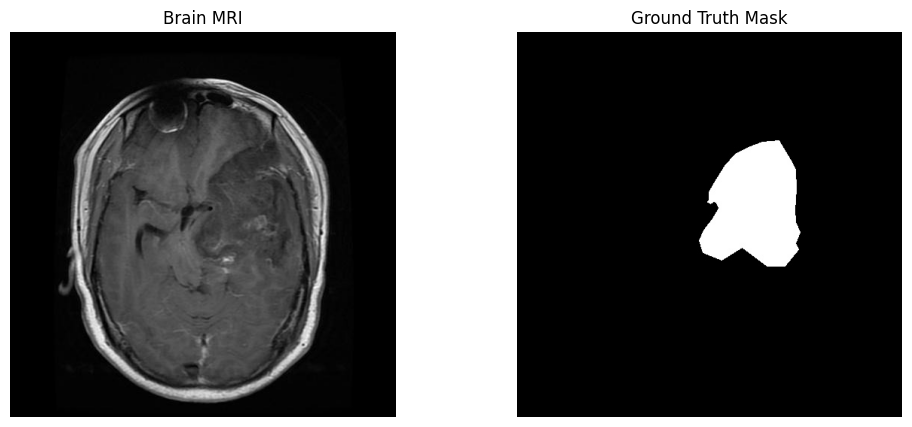

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Brain MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [17]:
from collections import Counter
import numpy as np
import cv2

mask = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)

unique, counts = np.unique(
    mask,
    return_counts=True
)

for value, count in zip(unique, counts):
    print(f"Value {value:3d}: {count:8d} pixels")

Value   0:   244991 pixels
Value   1:      398 pixels
Value   2:      227 pixels
Value   3:      117 pixels
Value   4:       39 pixels
Value   5:       20 pixels
Value   6:        6 pixels
Value   7:        1 pixels
Value 248:        2 pixels
Value 249:        2 pixels
Value 250:       26 pixels
Value 251:       44 pixels
Value 252:      111 pixels
Value 253:      220 pixels
Value 254:      413 pixels
Value 255:    15527 pixels


In [18]:
print("Minimum:", mask.min())
print("Maximum:", mask.max())
print("Unique values:", np.unique(mask))

Minimum: 0
Maximum: 255
Unique values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


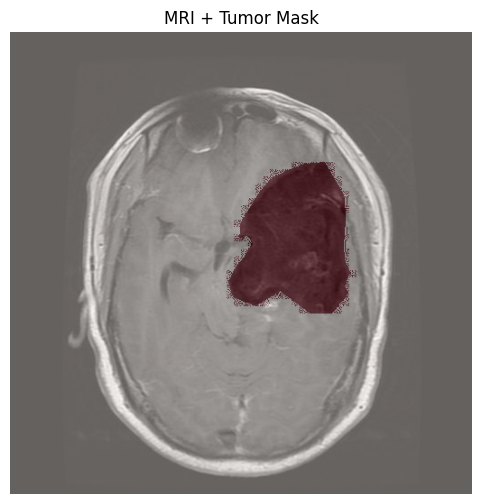

In [19]:
plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.imshow(mask > 0, alpha=0.4, cmap="Reds")

plt.title("MRI + Tumor Mask")
plt.axis("off")

plt.show()

In [20]:
IMAGE_SIZE = 256

BATCH_SIZE = 16

NUM_EPOCHS = 30

LEARNING_RATE = 1e-4

NUM_WORKERS = 2

SEED = 42

EARLY_STOPPING_PATIENCE = 5

MIN_DELTA = 0.001

In [21]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

In [22]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(
    train_pairs,
    test_size=0.15,
    random_state=SEED,
    shuffle=True
)

print("Training:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Testing:", len(test_pairs))

Training: 3343
Validation: 590
Testing: 860


In [23]:
train_transform = A.Compose([

    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.HorizontalFlip(
        p=0.5
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=10,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.3
    ),

    A.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),

    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [24]:
val_transform = A.Compose([

    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),

    ToTensorV2()
])

In [25]:
class BrainTumorDataset(Dataset):

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        image_path, mask_path = self.pairs[index]

        # -------------------------
        # Load MRI image
        # -------------------------
        image = cv2.imread(str(image_path))

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # -------------------------
        # Load segmentation mask
        # -------------------------
        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        # -------------------------
        # Convert mask to binary
        # -------------------------
        # 0-127   -> background
        # 128-255 -> tumor

        mask = (mask > 127).astype(
            np.float32
        )

        # -------------------------
        # Apply transformations
        # -------------------------
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # -------------------------
        # Add channel to mask
        # -------------------------
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        mask = mask.float()

        return image, mask

In [26]:
image_path, mask_path = train_pairs[0]

mask = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)

binary_mask = (
    mask > 127
).astype(np.uint8)

print("Original unique values:")
print(np.unique(mask))

print("\nBinary unique values:")
print(np.unique(binary_mask))

print("\nTumor pixels:")
print(np.sum(binary_mask == 1))

print("Background pixels:")
print(np.sum(binary_mask == 0))

Original unique values:
[  0   1   2   3   4   5   6 248 249 250 251 252 253 254 255]

Binary unique values:
[0 1]

Tumor pixels:
2025
Background pixels:
260119


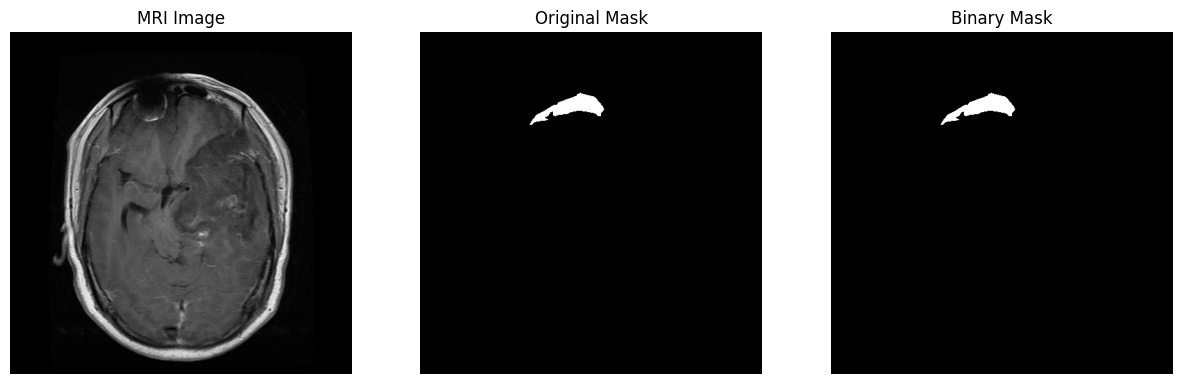

In [27]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)

plt.imshow(
    image
)

plt.title("MRI Image")

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    mask,
    cmap="gray"
)

plt.title("Original Mask")

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    binary_mask,
    cmap="gray"
)

plt.title("Binary Mask")

plt.axis("off")

plt.show()

In [28]:
train_dataset = BrainTumorDataset(
    train_pairs,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_pairs,
    transform=val_transform
)

test_dataset = BrainTumorDataset(
    test_pairs,
    transform=val_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 3343
Validation dataset: 590
Test dataset: 860


In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [30]:
print("Train workers:", train_loader.num_workers)
print("Val workers:", val_loader.num_workers)
print("Test workers:", test_loader.num_workers)

Train workers: 0
Val workers: 0
Test workers: 0


In [31]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks :", masks.shape)

Images: torch.Size([16, 3, 256, 256])
Masks : torch.Size([16, 1, 256, 256])


In [32]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.double_conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        return self.double_conv(x)

In [33]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(
            in_channels,
            64
        )

        self.enc2 = DoubleConv(
            64,
            128
        )

        self.enc3 = DoubleConv(
            128,
            256
        )

        self.enc4 = DoubleConv(
            256,
            512
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        # Output
        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)

        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        output = self.final(d1)

        return output

In [34]:
model = UNet(
    in_channels=3,
    out_channels=1
)

model = model.to(device)

print(model)

UNet(
  (enc1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
  

In [35]:
sample_images, sample_masks = next(iter(train_loader))

sample_images = sample_images.to(device)

with torch.no_grad():

    output = model(
        sample_images
    )

print("Input :", sample_images.shape)
print("Output:", output.shape)

Input : torch.Size([16, 3, 256, 256])
Output: torch.Size([16, 1, 256, 256])


In [36]:
def dice_score(
    predictions,
    targets,
    smooth=1e-6
):

    predictions = torch.sigmoid(
        predictions
    )

    predictions = (
        predictions > 0.5
    ).float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    dice = (
        2 * intersection + smooth
    ) / (
        predictions.sum(dim=1)
        +
        targets.sum(dim=1)
        +
        smooth
    )

    return dice.mean()

In [37]:
def dice_loss(
    predictions,
    targets,
    smooth=1e-6
):

    predictions = torch.sigmoid(
        predictions
    )

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    dice = (
        2 * intersection + smooth
    ) / (
        predictions.sum(dim=1)
        +
        targets.sum(dim=1)
        +
        smooth
    )

    return 1 - dice.mean()

In [38]:
bce_loss = nn.BCEWithLogitsLoss()


def combined_loss(
    predictions,
    targets
):

    bce = bce_loss(
        predictions,
        targets
    )

    dice = dice_loss(
        predictions,
        targets
    )

    return bce + dice

In [39]:
def iou_score(
    predictions,
    targets,
    smooth=1e-6
):

    predictions = torch.sigmoid(
        predictions
    )

    predictions = (
        predictions > 0.5
    ).float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    union = (
        predictions.sum(dim=1)
        +
        targets.sum(dim=1)
        -
        intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.mean()

In [40]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [41]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

In [42]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    running_dice = 0.0

    progress = tqdm(
        loader,
        desc="Training"
    )

    for images, masks in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        predictions = model(
            images
        )

        loss = combined_loss(
            predictions,
            masks
        )

        loss.backward()

        optimizer.step()

        dice = dice_score(
            predictions,
            masks
        )

        running_loss += (
            loss.item()
        )

        running_dice += (
            dice.item()
        )

        progress.set_postfix(
            loss=loss.item(),
            dice=dice.item()
        )

    epoch_loss = (
        running_loss /
        len(loader)
    )

    epoch_dice = (
        running_dice /
        len(loader)
    )

    return epoch_loss, epoch_dice

In [43]:
def validate(
    model,
    loader,
    device
):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    with torch.no_grad():

        progress = tqdm(
            loader,
            desc="Validation"
        )

        for images, masks in progress:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            predictions = model(
                images
            )

            loss = combined_loss(
                predictions,
                masks
            )

            dice = dice_score(
                predictions,
                masks
            )

            iou = iou_score(
                predictions,
                masks
            )

            running_loss += (
                loss.item()
            )

            running_dice += (
                dice.item()
            )

            running_iou += (
                iou.item()
            )

    epoch_loss = (
        running_loss /
        len(loader)
    )

    epoch_dice = (
        running_dice /
        len(loader)
    )

    epoch_iou = (
        running_iou /
        len(loader)
    )

    return (
        epoch_loss,
        epoch_dice,
        epoch_iou
    )

In [44]:
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0.001
    ):
        self.patience = patience
        self.min_delta = min_delta

        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, score):

        # First validation score
        if self.best_score is None:

            self.best_score = score
            self.counter = 0

            return False

        # Check if validation Dice improved
        if score > self.best_score + self.min_delta:

            self.best_score = score
            self.counter = 0

        else:

            self.counter += 1

            print(
                f"EarlyStopping: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

        return self.early_stop

In [45]:
early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001
)

best_dice = 0.0

In [ ]:
history = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}

best_dice = 0.0

early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001
)


for epoch in range(NUM_EPOCHS):

    print("\n" + "=" * 60)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    print("=" * 60)


    # ==========================================
    # Training
    # ==========================================

    train_loss, train_dice = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )


    # ==========================================
    # Validation
    # ==========================================

    val_loss, val_dice, val_iou = validate(
        model,
        val_loader,
        device
    )


    # ==========================================
    # Learning rate scheduler
    # ==========================================

    scheduler.step(
        val_dice
    )


    # ==========================================
    # Save history
    # ==========================================

    history["train_loss"].append(
        train_loss
    )

    history["train_dice"].append(
        train_dice
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_dice"].append(
        val_dice
    )

    history["val_iou"].append(
        val_iou
    )


    # ==========================================
    # Print results
    # ==========================================

    print("\nResults:")

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Dice : {train_dice:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Dice   : {val_dice:.4f}"
    )

    print(
        f"Val IoU    : {val_iou:.4f}"
    )


    # ==========================================
    # Save best model
    # ==========================================

    if val_dice > best_dice + 0.001:

        best_dice = val_dice

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou,
                "history": history
            },
            "best_brisc_unet.pth"
        )

        print(
            f"\n✓ Best model saved!"
        )

        print(
            f"✓ Best Validation Dice: "
            f"{best_dice:.4f}"
        )


    # ==========================================
    # Early stopping
    # ==========================================

    should_stop = early_stopping(
        val_dice
    )

    if should_stop:

        print("\n" + "=" * 60)

        print(
            "Early stopping triggered!"
        )

        print(
            f"Best Validation Dice: "
            f"{best_dice:.4f}"
        )

        print(
            f"Training stopped at epoch "
            f"{epoch + 1}"
        )

        print("=" * 60)

        break


Epoch 1/30


Training:   0%|          | 0/209 [00:00<?, ?it/s]

Validation:   0%|          | 0/37 [00:00<?, ?it/s]


Results:
Train Loss : 1.2701
Train Dice : 0.3903
Val Loss   : 1.1610
Val Dice   : 0.5592
Val IoU    : 0.4537

✓ Best model saved!
✓ Best Validation Dice: 0.5592

Epoch 2/30


Training:   0%|          | 0/209 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/37 [00:00<?, ?it/s]


Results:
Train Loss : 0.1369
Train Dice : 0.8853
Val Loss   : 0.1695
Val Dice   : 0.8569
Val IoU    : 0.7863

✓ Best model saved!
✓ Best Validation Dice: 0.8569

Epoch 30/30


Training:   0%|          | 0/209 [00:00<?, ?it/s]

Validation:   0%|          | 0/37 [00:00<?, ?it/s]


Results:
Train Loss : 0.1365
Train Dice : 0.8853
Val Loss   : 0.1676
Val Dice   : 0.8590
Val IoU    : 0.7869

✓ Best model saved!
✓ Best Validation Dice: 0.8590


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

model_path = "/content/drive/MyDrive/best_brisc_unet.pth"

print(os.path.exists(model_path))

True


In [47]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet(
    in_channels=3,
    out_channels=1
)

checkpoint = torch.load(
    "/content/drive/MyDrive/best_brisc_unet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [48]:
print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_dice', 'val_iou', 'history'])


In [49]:
print("Best epoch:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Validation IoU:", checkpoint["val_iou"])

Best epoch: 23
Validation Dice: 0.8513710369934907
Validation IoU: 0.7768538723120818


In [50]:
import numpy as np
from tqdm.auto import tqdm


def evaluate_model(
    model,
    test_loader,
    device,
    threshold=0.5,
    smooth=1e-7
):

    model.eval()

    total_loss = 0.0

    total_tp = 0
    total_tn = 0
    total_fp = 0
    total_fn = 0

    total_dice = 0.0
    total_iou = 0.0

    criterion = torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():

        progress = tqdm(
            test_loader,
            desc="Evaluating"
        )

        for images, masks in progress:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            # Model prediction
            logits = model(images)

            # Loss
            loss = criterion(
                logits,
                masks
            )

            total_loss += loss.item()

            # Convert logits to probabilities
            probabilities = torch.sigmoid(
                logits
            )

            # Convert probabilities to binary masks
            predictions = (
                probabilities >= threshold
            ).float()

            # Flatten
            predictions_flat = (
                predictions
                .view(-1)
            )

            masks_flat = (
                masks
                .view(-1)
            )

            # Confusion matrix values
            tp = (
                (predictions_flat == 1) &
                (masks_flat == 1)
            ).sum().item()

            tn = (
                (predictions_flat == 0) &
                (masks_flat == 0)
            ).sum().item()

            fp = (
                (predictions_flat == 1) &
                (masks_flat == 0)
            ).sum().item()

            fn = (
                (predictions_flat == 0) &
                (masks_flat == 1)
            ).sum().item()

            total_tp += tp
            total_tn += tn
            total_fp += fp
            total_fn += fn

            # Dice
            intersection = (
                predictions_flat *
                masks_flat
            ).sum().item()

            dice = (
                (2 * intersection + smooth) /
                (
                    predictions_flat.sum().item()
                    +
                    masks_flat.sum().item()
                    +
                    smooth
                )
            )

            total_dice += dice

            # IoU
            union = (
                predictions_flat.sum().item()
                +
                masks_flat.sum().item()
                -
                intersection
            )

            iou = (
                (intersection + smooth) /
                (union + smooth)
            )

            total_iou += iou

    # Average loss
    avg_loss = (
        total_loss /
        len(test_loader)
    )

    # Average Dice
    avg_dice = (
        total_dice /
        len(test_loader)
    )

    # Average IoU
    avg_iou = (
        total_iou /
        len(test_loader)
    )

    # Precision
    precision = (
        total_tp /
        (
            total_tp +
            total_fp +
            smooth
        )
    )

    # Recall
    recall = (
        total_tp /
        (
            total_tp +
            total_fn +
            smooth
        )
    )

    # F1
    f1 = (
        2 * precision * recall /
        (
            precision +
            recall +
            smooth
        )
    )

    # Pixel accuracy
    accuracy = (
        (total_tp + total_tn) /
        (
            total_tp +
            total_tn +
            total_fp +
            total_fn +
            smooth
        )
    )

    return {
        "loss": avg_loss,
        "dice": avg_dice,
        "iou": avg_iou,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

In [51]:
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    threshold=0.5
)

Evaluating:   0%|          | 0/54 [00:00<?, ?it/s]

In [52]:
print("\n" + "=" * 50)
print("BRISC2025 TEST SET RESULTS")
print("=" * 50)

print(
    f"Test Loss   : {results['loss']:.4f}"
)

print(
    f"Dice Score  : {results['dice']:.4f}"
)

print(
    f"IoU Score   : {results['iou']:.4f}"
)

print(
    f"Precision   : {results['precision']:.4f}"
)

print(
    f"Recall      : {results['recall']:.4f}"
)

print(
    f"F1 Score    : {results['f1']:.4f}"
)

print(
    f"Pixel Acc.  : {results['accuracy']:.4f}"
)

print("=" * 50)


BRISC2025 TEST SET RESULTS
Test Loss   : 0.0206
Dice Score  : 0.8765
IoU Score   : 0.7887
Precision   : 0.9117
Recall      : 0.8642
F1 Score    : 0.8873
Pixel Acc.  : 0.9958


In [53]:
def denormalize(image):

    mean = np.array(
        [0.5, 0.5, 0.5]
    )

    std = np.array(
        [0.5, 0.5, 0.5]
    )

    image = (
        image * std + mean
    )

    return np.clip(
        image,
        0,
        1
    )

In [54]:
images, masks = next(
    iter(test_loader)
)

images_gpu = images.to(device)

with torch.no_grad():

    logits = model(
        images_gpu
    )

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= 0.5
    ).float()

predictions = predictions.cpu()

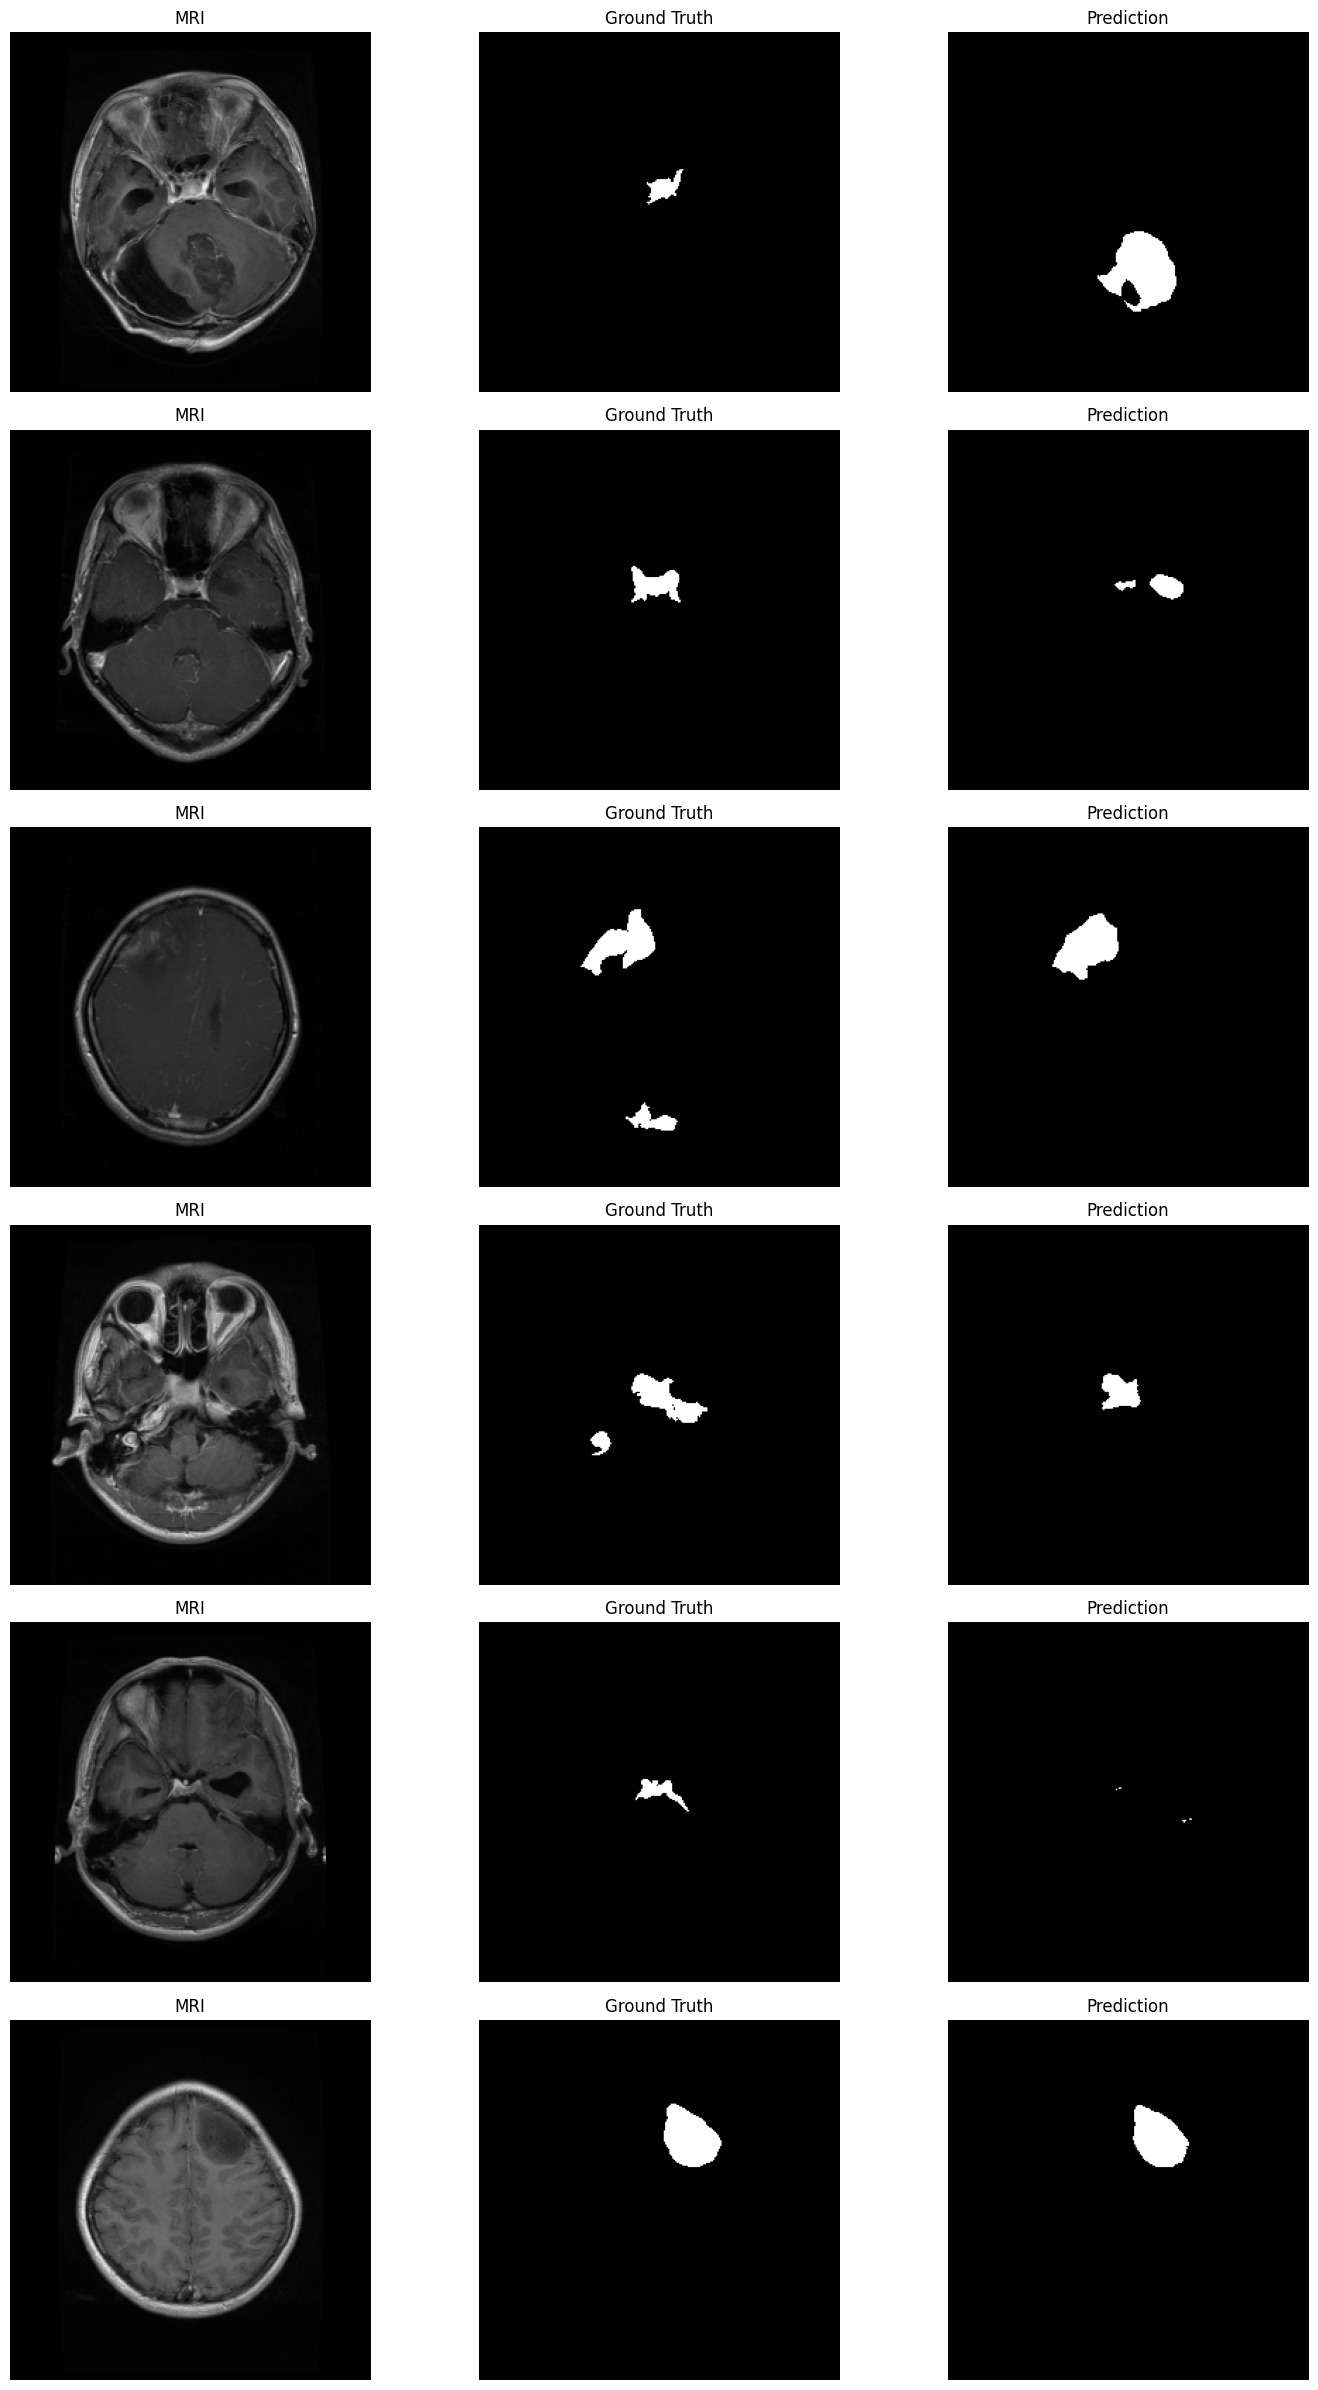

In [55]:
num_images = min(6, len(images))

plt.figure(
    figsize=(15, num_images * 4)
)

for i in range(num_images):

    image = images[i].permute(
        1, 2, 0
    ).numpy()

    image = denormalize(image)

    ground_truth = (
        masks[i]
        .squeeze()
        .numpy()
    )

    prediction = (
        predictions[i]
        .squeeze()
        .numpy()
    )

    # MRI
    plt.subplot(
        num_images,
        3,
        i * 3 + 1
    )

    plt.imshow(image)

    plt.title("MRI")

    plt.axis("off")

    # Ground Truth
    plt.subplot(
        num_images,
        3,
        i * 3 + 2
    )

    plt.imshow(
        ground_truth,
        cmap="gray"
    )

    plt.title("Ground Truth")

    plt.axis("off")

    # Prediction
    plt.subplot(
        num_images,
        3,
        i * 3 + 3
    )

    plt.imshow(
        prediction,
        cmap="gray"
    )

    plt.title("Prediction")

    plt.axis("off")


plt.tight_layout()

plt.show()

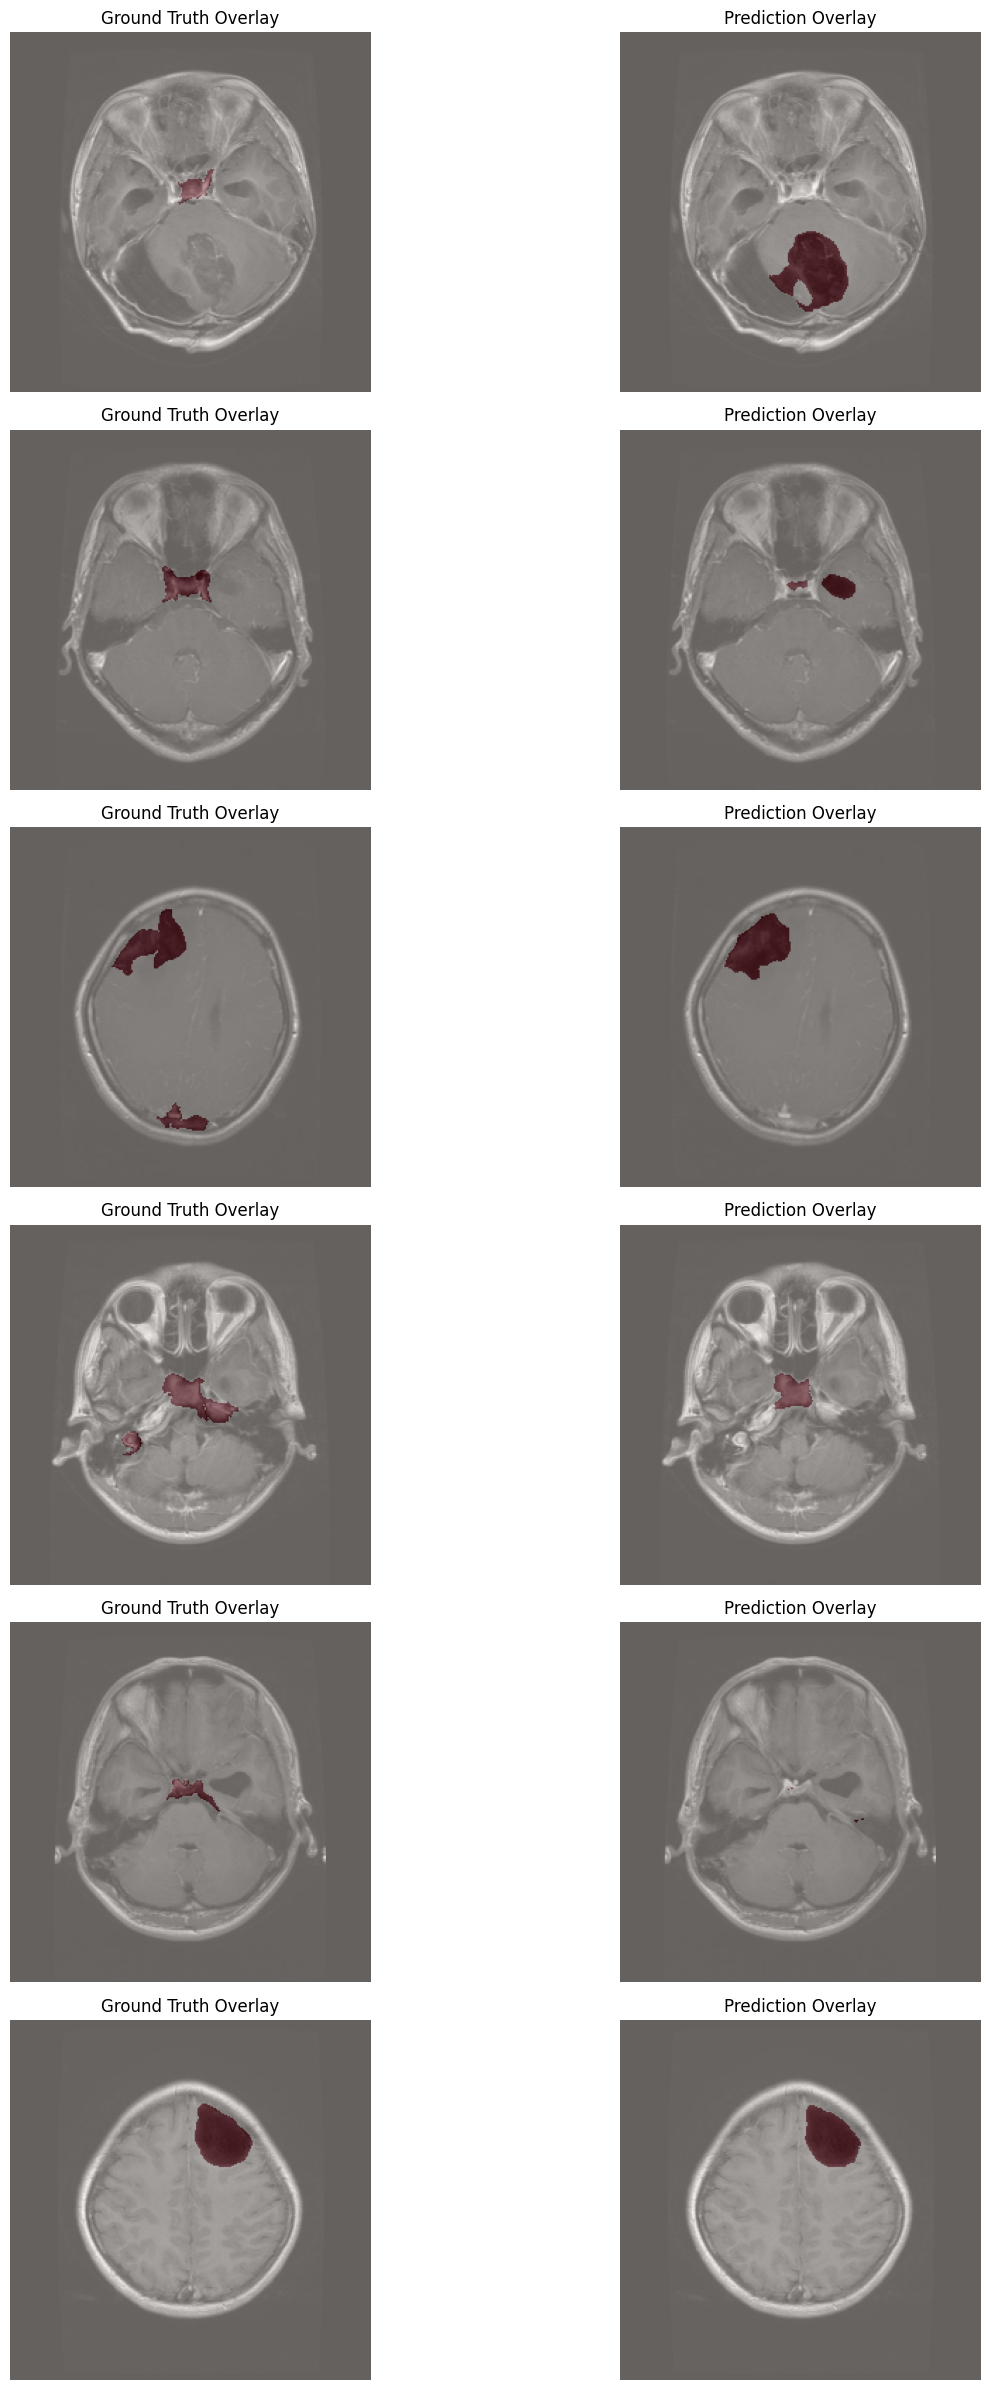

In [56]:
plt.figure(
    figsize=(15, num_images * 4)
)

for i in range(num_images):

    image = images[i].permute(
        1, 2, 0
    ).numpy()

    image = denormalize(image)

    ground_truth = (
        masks[i]
        .squeeze()
        .numpy()
    )

    prediction = (
        predictions[i]
        .squeeze()
        .numpy()
    )

    # Ground truth overlay
    plt.subplot(
        num_images,
        2,
        i * 2 + 1
    )

    plt.imshow(image)

    plt.imshow(
        ground_truth,
        alpha=0.4,
        cmap="Reds"
    )

    plt.title("Ground Truth Overlay")

    plt.axis("off")

    # Prediction overlay
    plt.subplot(
        num_images,
        2,
        i * 2 + 2
    )

    plt.imshow(image)

    plt.imshow(
        prediction,
        alpha=0.4,
        cmap="Reds"
    )

    plt.title("Prediction Overlay")

    plt.axis("off")


plt.tight_layout()

plt.show()

In [57]:
import json

with open(
    "BRISC2025_evaluation_results.json",
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )

print(
    "Evaluation results saved."
)

Evaluation results saved.
